# Hyperparameter Optimization (HPO) on a Single Estimator  
**Focus:** tune one estimator end-to-end using multiple HPO strategies (Grid, Random, Bayesian Optimization, Hyperband-style early stopping, and BOHB-style multi-fidelity).

We will use the *same estimator family* for both:
- **Classification:** `HistGradientBoostingClassifier`
- **Regression:** `HistGradientBoostingRegressor`

You will see many fully solved examples **plus two student tasks** (one classification, one regression) at the end.



## Learning objectives
By the end of this notebook, you should be able to:
1. Define a *search space* for a model and understand which hyperparameters matter.
2. Run and compare different HPO methods under a **fixed budget**.
3. Understand early-stopping / multi-fidelity tuning (Hyperband idea).
4. Read, interpret, and present tuning results: best config, learning curves, and test-set performance.



## Setup
We aim for **reproducible** experiments.  
We keep an untouched **test set** to avoid "tuning on the test".


In [1]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 5.7 MB/s eta 0:00:00


In [2]:

# If you run this in a fresh environment, you may need:
# pip install optuna

import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import Dict, Any, Tuple, List

from sklearn.datasets import load_breast_cancer, fetch_california_housing
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, accuracy_score, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor

import optuna
from optuna.pruners import MedianPruner, HyperbandPruner
from optuna.samplers import TPESampler

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)



## Helper utilities
These functions standardize:
- metric computation
- timing
- plotting best-so-far curves


In [3]:

@dataclass
class RunResult:
    method: str
    best_params: Dict[str, Any]
    best_val_score: float
    test_score: float
    elapsed_s: float
    n_evals: int
    notes: str = ""

def timer(func):
    def wrapped(*args, **kwargs):
        t0 = time.time()
        out = func(*args, **kwargs)
        t1 = time.time()
        return out, (t1 - t0)
    return wrapped

def plot_best_so_far(scores: List[float], title: str, higher_is_better: bool = True):
    if len(scores) == 0:
        return
    best = []
    cur = -np.inf if higher_is_better else np.inf
    for s in scores:
        if higher_is_better:
            cur = max(cur, s)
        else:
            cur = min(cur, s)
        best.append(cur)
    plt.figure()
    plt.plot(best)
    plt.xlabel("Trial")
    plt.ylabel("Best so far")
    plt.title(title)
    plt.show()

def summarize_results(results: List[RunResult]) -> pd.DataFrame:
    df = pd.DataFrame([{
        "method": r.method,
        "best_val_score": r.best_val_score,
        "test_score": r.test_score,
        "elapsed_s": r.elapsed_s,
        "n_evals": r.n_evals,
        "notes": r.notes
    } for r in results]).sort_values(by="best_val_score", ascending=False)
    return df



## Part A — Data for classification and regression
We use two classic, lightweight datasets:
- **Classification:** Breast Cancer (binary). Metric: **ROC-AUC** (primary) and Accuracy (secondary).
- **Regression:** California Housing. Metric: **RMSE** (primary, lower is better) and R² (secondary).

We build *pipelines* so preprocessing is consistently applied.


In [4]:

# -------------------------
# Classification dataset
# -------------------------
#breast cancer is too easy
# Xc, yc = load_breast_cancer(return_X_y=True, as_frame=True)
from sklearn.datasets import fetch_openml
Xc, yc = fetch_openml("spambase", version=1, as_frame=True, return_X_y=True)
yc = yc.astype(int)   # target often comes as strings

Xc_trainval, Xc_test, yc_trainval, yc_test = train_test_split(
    Xc, yc, test_size=0.2, random_state=RANDOM_SEED, stratify=yc
)

# A simple pipeline (impute just in case; scaling not required for trees but kept for good practice)
clf_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", HistGradientBoostingClassifier(
        random_state=RANDOM_SEED,
        max_iter=30,            # small budget => weaker baseline
        learning_rate=0.1,
        max_leaf_nodes=15,      # restrict complexity
        max_depth=3,            # shallow trees
        l2_regularization=0.2,  # stronger regularization
        early_stopping=False    # keep deterministic behavior
    ))
])

# -------------------------
# Regression dataset
# -------------------------
Xr, yr = fetch_california_housing(return_X_y=True, as_frame=True)

Xr_trainval, Xr_test, yr_trainval, yr_test = train_test_split(
    Xr, yr, test_size=0.2, random_state=RANDOM_SEED
)

reg_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", HistGradientBoostingRegressor(
        random_state=RANDOM_SEED,
        max_iter=60,            # small budget => weaker baseline
        learning_rate=0.1,
        max_leaf_nodes=15,
        max_depth=3,
        l2_regularization=0.2,
        early_stopping=False
    ))
])

print("Classification:", Xc_trainval.shape, "train/val;", Xc_test.shape, "test")
print("Regression:", Xr_trainval.shape, "train/val;", Xr_test.shape, "test")


Classification: (3680, 57) train/val; (921, 57) test
Regression: (16512, 8) train/val; (4128, 8) test



## Baselines (no tuning)
Before tuning, we measure performance with default hyperparameters.


In [5]:

# Classification baseline
clf_pipe.fit(Xc_trainval, yc_trainval)
proba = clf_pipe.predict_proba(Xc_test)[:, 1]
pred = (proba >= 0.5).astype(int)

base_auc = roc_auc_score(yc_test, proba)
base_acc = accuracy_score(yc_test, pred)

# Regression baseline
reg_pipe.fit(Xr_trainval, yr_trainval)
pred_r = reg_pipe.predict(Xr_test)

base_rmse = math.sqrt(mean_squared_error(yr_test, pred_r))
base_r2 = r2_score(yr_test, pred_r)

print(f"Classification baseline: ROC-AUC={base_auc:.4f}, ACC={base_acc:.4f}")
print(f"Regression baseline: RMSE={base_rmse:.4f}, R2={base_r2:.4f}")


Classification baseline: ROC-AUC=0.9744, ACC=0.9207
Regression baseline: RMSE=0.5690, R2=0.7530



## Search space
We tune a **single estimator** (`HistGradientBoosting*`) using common hyperparameters.

> Note: in this notebook, we treat `max_iter` as a **training budget** for multi-fidelity methods (Hyperband-like).  
This allows early stopping / pruning of weak configurations.


In [6]:

# Parameter grids/ranges for sklearn searches (prefix with 'model__' because the model lives inside the Pipeline)

# A small grid for Grid Search (keep it small so it runs fast in class)
grid_params_clf = {
    "model__learning_rate": [0.03, 0.1],
    "model__max_depth": [3, 6],
    "model__max_leaf_nodes": [15, 31],
    "model__l2_regularization": [0.0, 0.1],
    "model__max_iter": [200],  # keep fixed for Grid Search to reduce explosion
}

grid_params_reg = {
    "model__learning_rate": [0.03, 0.1],
    "model__max_depth": [3, 6],
    "model__max_leaf_nodes": [15, 31],
    "model__l2_regularization": [0.0, 0.1],
    "model__max_iter": [300],  # regression sometimes benefits from a bit more
}

# Distributions for Random Search
rand_params_clf = {
    "model__learning_rate": np.logspace(-2.0, -0.5, 50),
    "model__max_depth": [2, 3, 4, 5, 6, 8, None],
    "model__max_leaf_nodes": list(range(10, 65)),
    "model__l2_regularization": np.linspace(0.0, 1.0, 50),
    "model__min_samples_leaf": list(range(10, 101, 5)),
    "model__max_iter": [200],
}

rand_params_reg = {
    "model__learning_rate": np.logspace(-2.0, -0.5, 50),
    "model__max_depth": [2, 3, 4, 5, 6, 8, None],
    "model__max_leaf_nodes": list(range(10, 65)),
    "model__l2_regularization": np.linspace(0.0, 1.0, 50),
    "model__min_samples_leaf": list(range(10, 101, 5)),
    "model__max_iter": [300],
}



## Method 1 — Grid Search (solved)
Grid search enumerates all combinations in a small discrete grid.


In [7]:

@timer
def run_grid_search_clf():
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    gs = GridSearchCV(
        clf_pipe,
        param_grid=grid_params_clf,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
        verbose=0,
    )
    gs.fit(Xc_trainval, yc_trainval)

    best_params = gs.best_params_
    best_val = gs.best_score_

    # Evaluate on test
    best_model = gs.best_estimator_
    proba = best_model.predict_proba(Xc_test)[:, 1]
    test_auc = roc_auc_score(yc_test, proba)

    return best_params, best_val, test_auc, gs

(best_params, best_val, test_auc, gs_obj), elapsed = run_grid_search_clf()
print("Best params:", best_params)
print(f"Best CV ROC-AUC: {best_val:.4f}")
print(f"Test ROC-AUC: {test_auc:.4f}")
print(f"Elapsed: {elapsed:.2f}s; evaluated: {len(gs_obj.cv_results_['mean_test_score'])}")


Best params: {'model__l2_regularization': 0.0, 'model__learning_rate': 0.1, 'model__max_depth': 6, 'model__max_iter': 200, 'model__max_leaf_nodes': 31}
Best CV ROC-AUC: 0.9877
Test ROC-AUC: 0.9878
Elapsed: 52.27s; evaluated: 16


In [8]:

# Inspect top configurations (solved)
df_gs = pd.DataFrame(gs_obj.cv_results_)
top = df_gs.sort_values("mean_test_score", ascending=False).head(8)[
    ["mean_test_score", "std_test_score", "params"]
]
top


,mean_test_score,std_test_score,params
7,0.987685,0.003577,"{'model__l2_regularization': 0.0, 'model__lear..."
6,0.987510,0.003282,"{'model__l2_regularization': 0.0, 'model__lear..."
15,0.987466,0.003312,"{'model__l2_regularization': 0.1, 'model__lear..."
14,0.987411,0.003155,"{'model__l2_regularization': 0.1, 'model__lear..."
11,0.986213,0.003182,"{'model__l2_regularization': 0.1, 'model__lear..."
4,0.986185,0.003229,"{'model__l2_regularization': 0.0, 'model__lear..."
3,0.986185,0.003096,"{'model__l2_regularization': 0.0, 'model__lear..."
5,0.986185,0.003229,"{'model__l2_regularization': 0.0, 'model__lear..."



### Grid Search (regression) — solved
For regression we use negative RMSE for scoring in sklearn. We'll convert back to RMSE for readability.


In [9]:

@timer
def run_grid_search_reg():
    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    gs = GridSearchCV(
        reg_pipe,
        param_grid=grid_params_reg,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=-1,
        verbose=0,
    )
    gs.fit(Xr_trainval, yr_trainval)

    best_params = gs.best_params_
    best_val_neg_rmse = gs.best_score_
    best_val_rmse = -best_val_neg_rmse

    best_model = gs.best_estimator_
    pred = best_model.predict(Xr_test)
    test_rmse = math.sqrt(mean_squared_error(yr_test, pred))
    # mean_squared_error(yr_test, pred, squared=False)

    return best_params, best_val_rmse, test_rmse, gs

(best_params_r, best_val_rmse, test_rmse, gs_obj_r), elapsed_r = run_grid_search_reg()
print("Best params:", best_params_r)
print(f"Best CV RMSE: {best_val_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Elapsed: {elapsed_r:.2f}s; evaluated: {len(gs_obj_r.cv_results_['mean_test_score'])}")


Best params: {'model__l2_regularization': 0.0, 'model__learning_rate': 0.1, 'model__max_depth': 6, 'model__max_iter': 300, 'model__max_leaf_nodes': 31}
Best CV RMSE: 0.4584
Test RMSE: 0.4455
Elapsed: 54.53s; evaluated: 16



## Method 2 — Random Search (solved)
Random search samples hyperparameters from distributions.  
In higher-dimensional spaces, it often outperforms grid for the same budget.


Best params: {'model__min_samples_leaf': 55, 'model__max_leaf_nodes': 64, 'model__max_iter': 200, 'model__max_depth': None, 'model__learning_rate': np.float64(0.08286427728546843), 'model__l2_regularization': np.float64(0.26530612244897955)}
Best CV ROC-AUC: 0.9874
Test ROC-AUC: 0.9866
Elapsed: 115.36s; evaluated: 40


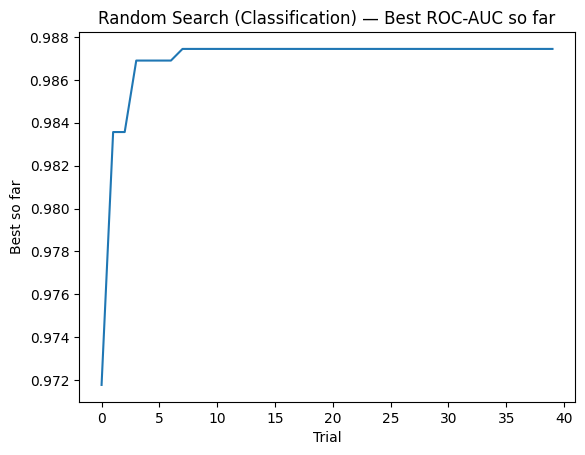

In [10]:

@timer
def run_random_search_clf(n_iter=40):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    rs = RandomizedSearchCV(
        clf_pipe,
        param_distributions=rand_params_clf,
        n_iter=n_iter,
        scoring="roc_auc",
        cv=cv,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        verbose=0,
    )
    rs.fit(Xc_trainval, yc_trainval)

    best_params = rs.best_params_
    best_val = rs.best_score_

    best_model = rs.best_estimator_
    proba = best_model.predict_proba(Xc_test)[:, 1]
    test_auc = roc_auc_score(yc_test, proba)

    trial_scores = rs.cv_results_["mean_test_score"].tolist()
    return best_params, best_val, test_auc, trial_scores, rs

(best_params, best_val, test_auc, scores, rs_obj), elapsed = run_random_search_clf(n_iter=40)
print("Best params:", best_params)
print(f"Best CV ROC-AUC: {best_val:.4f}")
print(f"Test ROC-AUC: {test_auc:.4f}")
print(f"Elapsed: {elapsed:.2f}s; evaluated: {len(scores)}")

plot_best_so_far(scores, "Random Search (Classification) — Best ROC-AUC so far", higher_is_better=True)


Best params: {'model__min_samples_leaf': 55, 'model__max_leaf_nodes': 64, 'model__max_iter': 300, 'model__max_depth': None, 'model__learning_rate': np.float64(0.08286427728546843), 'model__l2_regularization': np.float64(0.26530612244897955)}
Best CV RMSE: 0.4525
Test RMSE: 0.4393
Elapsed: 158.68s; evaluated: 40


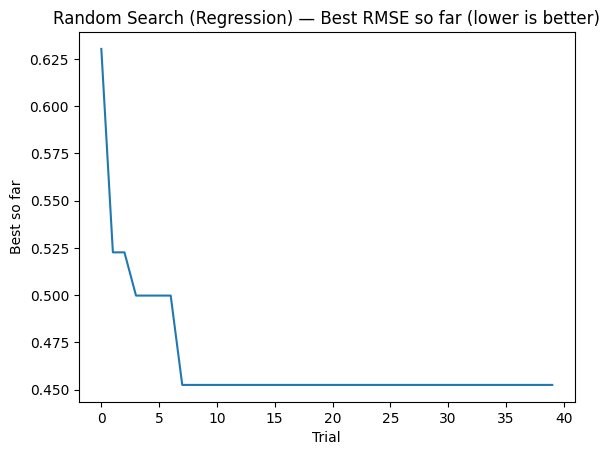

In [ ]:

@timer
def run_random_search_reg(n_iter=40):
    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    rs = RandomizedSearchCV(
        reg_pipe,
        param_distributions=rand_params_reg,
        n_iter=n_iter,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        verbose=0,
    )
    rs.fit(Xr_trainval, yr_trainval)

    best_params = rs.best_params_
    best_val_rmse = -rs.best_score_

    best_model = rs.best_estimator_
    pred = best_model.predict(Xr_test)
    test_rmse = math.sqrt(mean_squared_error(yr_test, pred))
    #mean_squared_error(yr_test, pred, squared=False)

    # Convert neg RMSE to RMSE for per-trial series
    trial_rmse = [-s for s in rs.cv_results_["mean_test_score"].tolist()]
    return best_params, best_val_rmse, test_rmse, trial_rmse, rs

(best_params, best_val_rmse, test_rmse, rmses, rs_obj_r), elapsed = run_random_search_reg(n_iter=40)
print("Best params:", best_params)
print(f"Best CV RMSE: {best_val_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Elapsed: {elapsed:.2f}s; evaluated: {len(rmses)}")

plot_best_so_far(rmses, "Random Search (Regression) — Best RMSE so far (lower is better)", higher_is_better=False)



## Method 3 — Bayesian Optimization (BO) via Optuna TPE (solved)
Optuna's default TPE sampler is a practical Bayesian-optimization-style approach.

We define an objective that:
- samples hyperparameters
- runs cross-validation
- returns validation score


In [ ]:

def suggest_hgb_params(trial: optuna.Trial, task: str, max_iter_fixed: int) -> Dict[str, Any]:
    # Hyperparameters shared across classifier/regressor
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_categorical("max_depth", [2, 3, 4, 5, 6, None]),
        "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 10, 64),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 10, 100, step=5),
        "l2_regularization": trial.suggest_float("l2_regularization", 0.0, 1.0),
        "max_iter": max_iter_fixed,
    }
    return params

def cv_score_classification(params: Dict[str, Any], n_splits=5) -> float:
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)
    scores = []
    for tr_idx, va_idx in cv.split(Xc_trainval, yc_trainval):
        Xtr, Xva = Xc_trainval.iloc[tr_idx], Xc_trainval.iloc[va_idx]
        ytr, yva = yc_trainval.iloc[tr_idx], yc_trainval.iloc[va_idx]

        model = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", HistGradientBoostingClassifier(random_state=RANDOM_SEED, **params))
        ])
        model.fit(Xtr, ytr)
        proba = model.predict_proba(Xva)[:, 1]
        scores.append(roc_auc_score(yva, proba))
    return float(np.mean(scores))

def cv_score_regression_rmse(params: Dict[str, Any], n_splits=5) -> float:
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)
    rmses = []
    for tr_idx, va_idx in cv.split(Xr_trainval, yr_trainval):
        Xtr, Xva = Xr_trainval.iloc[tr_idx], Xr_trainval.iloc[va_idx]
        ytr, yva = yr_trainval.iloc[tr_idx], yr_trainval.iloc[va_idx]

        model = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", HistGradientBoostingRegressor(random_state=RANDOM_SEED, **params))
        ])
        model.fit(Xtr, ytr)
        pred = model.predict(Xva)
        rmses.append(math.sqrt(mean_squared_error(yva, pred)))
    return float(np.mean(rmses))


[I 2026-02-04 13:08:49,352] A new study created in memory with name: no-name-66c1acec-0f06-42f2-b450-6c3f87c06d5d
[I 2026-02-04 13:08:51,192] Trial 0 finished with value: 0.9807337250657182 and parameters: {'learning_rate': 0.03574712922600244, 'max_depth': 2, 'max_leaf_nodes': 57, 'min_samples_leaf': 65, 'l2_regularization': 0.7080725777960455}. Best is trial 0 with value: 0.9807337250657182.
[I 2026-02-04 13:08:53,081] Trial 1 finished with value: 0.9669870109788155 and parameters: {'learning_rate': 0.010725209743171997, 'max_depth': 2, 'max_leaf_nodes': 38, 'min_samples_leaf': 50, 'l2_regularization': 0.2912291401980419}. Best is trial 0 with value: 0.9807337250657182.
[I 2026-02-04 13:08:56,464] Trial 2 finished with value: 0.9871145817225916 and parameters: {'learning_rate': 0.08012737503998542, 'max_depth': 6, 'max_leaf_nodes': 38, 'min_samples_leaf': 65, 'l2_regularization': 0.046450412719997725}. Best is trial 2 with value: 0.9871145817225916.
[I 2026-02-04 13:08:59,811] Trial 

Best params: {'learning_rate': 0.20313159876519316, 'max_depth': 6, 'max_leaf_nodes': 40, 'min_samples_leaf': 15, 'l2_regularization': 0.6519238847352421, 'max_iter': 200}
Best CV ROC-AUC: 0.9880
Test ROC-AUC: 0.9863
Elapsed: 159.50s; trials: 40


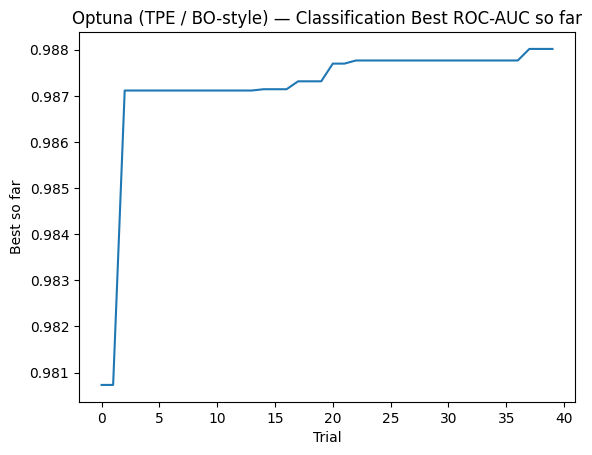

In [ ]:

@timer
def run_optuna_bo_clf(n_trials=40):
    sampler = TPESampler(seed=RANDOM_SEED)
    study = optuna.create_study(direction="maximize", sampler=sampler)

    trial_scores = []

    def objective(trial):
        params = suggest_hgb_params(trial, task="clf", max_iter_fixed=200)
        score = cv_score_classification(params, n_splits=5)
        trial_scores.append(score)
        return score

    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    best_params = study.best_params.copy()
    best_params["max_iter"] = 200

    # Fit best on full trainval and evaluate test
    best_model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", HistGradientBoostingClassifier(random_state=RANDOM_SEED, **best_params))
    ])
    best_model.fit(Xc_trainval, yc_trainval)
    proba = best_model.predict_proba(Xc_test)[:, 1]
    test_auc = roc_auc_score(yc_test, proba)

    return best_params, float(study.best_value), test_auc, trial_scores, study

(best_params, best_val, test_auc, scores, study), elapsed = run_optuna_bo_clf(n_trials=40)
print("Best params:", best_params)
print(f"Best CV ROC-AUC: {best_val:.4f}")
print(f"Test ROC-AUC: {test_auc:.4f}")
print(f"Elapsed: {elapsed:.2f}s; trials: {len(scores)}")

plot_best_so_far(scores, "Optuna (TPE / BO-style) — Classification Best ROC-AUC so far", higher_is_better=True)


[I 2026-02-04 13:23:39,849] A new study created in memory with name: no-name-345b21ee-f97e-413f-b5f5-bc6f6e690083
[I 2026-02-04 13:23:42,417] Trial 0 finished with value: 0.5701054195736169 and parameters: {'learning_rate': 0.03574712922600244, 'max_depth': 2, 'max_leaf_nodes': 57, 'min_samples_leaf': 65, 'l2_regularization': 0.7080725777960455}. Best is trial 0 with value: 0.5701054195736169.
[I 2026-02-04 13:23:47,501] Trial 1 finished with value: 0.6980858606059038 and parameters: {'learning_rate': 0.010725209743171997, 'max_depth': 2, 'max_leaf_nodes': 38, 'min_samples_leaf': 50, 'l2_regularization': 0.2912291401980419}. Best is trial 0 with value: 0.5701054195736169.
[I 2026-02-04 13:23:53,461] Trial 2 finished with value: 0.46810709119014476 and parameters: {'learning_rate': 0.08012737503998542, 'max_depth': 6, 'max_leaf_nodes': 38, 'min_samples_leaf': 65, 'l2_regularization': 0.046450412719997725}. Best is trial 2 with value: 0.46810709119014476.
[I 2026-02-04 13:23:58,234] Tria

Best params: {'learning_rate': 0.07435557885232344, 'max_depth': None, 'max_leaf_nodes': 30, 'min_samples_leaf': 50, 'l2_regularization': 0.33413172545065073, 'max_iter': 300}
Best CV RMSE: 0.4599
Test RMSE: 0.4479
Elapsed: 191.03s; trials: 40


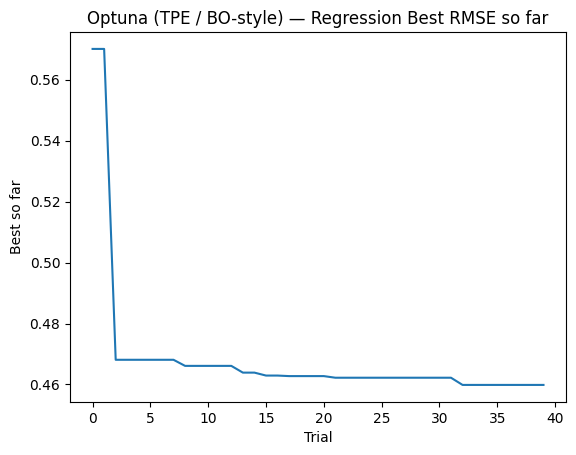

In [ ]:

@timer
def run_optuna_bo_reg(n_trials=40):
    sampler = TPESampler(seed=RANDOM_SEED)
    study = optuna.create_study(direction="minimize", sampler=sampler)

    trial_rmses = []

    def objective(trial):
        params = suggest_hgb_params(trial, task="reg", max_iter_fixed=300)
        rmse = cv_score_regression_rmse(params, n_splits=5)
        trial_rmses.append(rmse)
        return rmse

    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    best_params = study.best_params.copy()
    best_params["max_iter"] = 300

    best_model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", HistGradientBoostingRegressor(random_state=RANDOM_SEED, **best_params))
    ])
    best_model.fit(Xr_trainval, yr_trainval)
    pred = best_model.predict(Xr_test)
    test_rmse = math.sqrt(mean_squared_error(yr_test, pred))
    #mean_squared_error(yr_test, pred, squared=False)

    return best_params, float(study.best_value), test_rmse, trial_rmses, study

(best_params, best_val_rmse, test_rmse, rmses, study_r), elapsed = run_optuna_bo_reg(n_trials=40)
print("Best params:", best_params)
print(f"Best CV RMSE: {best_val_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Elapsed: {elapsed:.2f}s; trials: {len(rmses)}")

plot_best_so_far(rmses, "Optuna (TPE / BO-style) — Regression Best RMSE so far", higher_is_better=False)



## Method 4 — Hyperband-style multi-fidelity (solved)
Hyperband allocates **increasing budgets** to better candidates.

We approximate this using Optuna's `HyperbandPruner` and treat:
- **budget** = `max_iter`

Each trial reports intermediate results at increasing budgets so Optuna can prune early.


In [ ]:

def incremental_cv_auc(trial, base_params, budgets=(50, 100, 200), n_splits=3):
    # Faster CV for multi-fidelity: fewer splits
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)
    best_at_budget = None
    for step, b in enumerate(budgets):
        params = dict(base_params)
        params["max_iter"] = b

        scores = []
        for tr_idx, va_idx in cv.split(Xc_trainval, yc_trainval):
            Xtr, Xva = Xc_trainval.iloc[tr_idx], Xc_trainval.iloc[va_idx]
            ytr, yva = yc_trainval.iloc[tr_idx], yc_trainval.iloc[va_idx]

            model = Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("model", HistGradientBoostingClassifier(random_state=RANDOM_SEED, **params))
            ])
            model.fit(Xtr, ytr)
            proba = model.predict_proba(Xva)[:, 1]
            scores.append(roc_auc_score(yva, proba))

        score = float(np.mean(scores))
        best_at_budget = score

        # Report intermediate value for pruning
        trial.report(score, step=step)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return best_at_budget

def incremental_cv_rmse(trial, base_params, budgets=(80, 150, 300), n_splits=3):
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)
    best_at_budget = None
    for step, b in enumerate(budgets):
        params = dict(base_params)
        params["max_iter"] = b

        rmses = []
        for tr_idx, va_idx in cv.split(Xr_trainval, yr_trainval):
            Xtr, Xva = Xr_trainval.iloc[tr_idx], Xr_trainval.iloc[va_idx]
            ytr, yva = yr_trainval.iloc[tr_idx], yr_trainval.iloc[va_idx]

            model = Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("model", HistGradientBoostingRegressor(random_state=RANDOM_SEED, **params))
            ])
            model.fit(Xtr, ytr)
            pred = model.predict(Xva)
            rmses.append(math.sqrt(mean_squared_error(yva, pred)))

        rmse = float(np.mean(rmses))
        best_at_budget = rmse

        trial.report(rmse, step=step)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return best_at_budget


[I 2026-02-04 13:28:54,778] A new study created in memory with name: no-name-c572a288-96f4-43ed-a941-c3106a4d9ac2
[I 2026-02-04 13:28:56,726] Trial 0 finished with value: 0.9807344716695221 and parameters: {'learning_rate': 0.03574712922600244, 'max_depth': 2, 'max_leaf_nodes': 57, 'min_samples_leaf': 65, 'l2_regularization': 0.7080725777960455}. Best is trial 0 with value: 0.9807344716695221.
[I 2026-02-04 13:28:58,710] Trial 1 finished with value: 0.9679556481268868 and parameters: {'learning_rate': 0.010725209743171997, 'max_depth': 2, 'max_leaf_nodes': 38, 'min_samples_leaf': 50, 'l2_regularization': 0.2912291401980419}. Best is trial 0 with value: 0.9807344716695221.
[I 2026-02-04 13:29:02,667] Trial 2 finished with value: 0.986936182039693 and parameters: {'learning_rate': 0.08012737503998542, 'max_depth': 6, 'max_leaf_nodes': 38, 'min_samples_leaf': 65, 'l2_regularization': 0.046450412719997725}. Best is trial 2 with value: 0.986936182039693.
[I 2026-02-04 13:29:04,844] Trial 3 

Best params: {'learning_rate': 0.10596067942279158, 'max_depth': 6, 'max_leaf_nodes': 16, 'min_samples_leaf': 20, 'l2_regularization': 0.6276429452559498, 'max_iter': 200}
Best (multi-fidelity) val ROC-AUC: 0.9879
Test ROC-AUC: 0.9870
Elapsed: 178.44s; completed trials: 36; pruned: 14


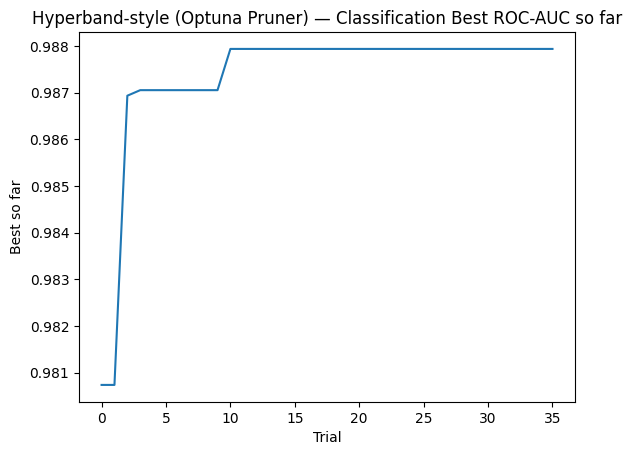

In [ ]:

@timer
def run_hyperband_style_clf(n_trials=50):
    sampler = TPESampler(seed=RANDOM_SEED)  # sampling strategy can be random or TPE; pruning is the key here
    pruner = HyperbandPruner()
    study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)

    values = []
    def objective(trial):
        base_params = {
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "max_depth": trial.suggest_categorical("max_depth", [2, 3, 4, 5, 6, None]),
            "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 10, 64),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 10, 100, step=5),
            "l2_regularization": trial.suggest_float("l2_regularization", 0.0, 1.0),
        }
        val = incremental_cv_auc(trial, base_params, budgets=(50, 100, 200), n_splits=3)
        values.append(val)
        return val

    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    best_params = study.best_params.copy()
    best_params["max_iter"] = 200

    best_model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", HistGradientBoostingClassifier(random_state=RANDOM_SEED, **best_params))
    ])
    best_model.fit(Xc_trainval, yc_trainval)
    proba = best_model.predict_proba(Xc_test)[:, 1]
    test_auc = roc_auc_score(yc_test, proba)

    return best_params, float(study.best_value), test_auc, values, study

(best_params, best_val, test_auc, values, hb_study), elapsed = run_hyperband_style_clf(n_trials=50)
print("Best params:", best_params)
print(f"Best (multi-fidelity) val ROC-AUC: {best_val:.4f}")
print(f"Test ROC-AUC: {test_auc:.4f}")
print(f"Elapsed: {elapsed:.2f}s; completed trials: {len(values)}; pruned: {len([t for t in hb_study.trials if t.state==optuna.trial.TrialState.PRUNED])}")

plot_best_so_far(values, "Hyperband-style (Optuna Pruner) — Classification Best ROC-AUC so far", higher_is_better=True)


[I 2026-02-04 13:43:29,592] A new study created in memory with name: no-name-7ee66475-c6d5-4205-9227-231e7c291824
[I 2026-02-04 13:43:32,164] Trial 0 finished with value: 0.57086167398703 and parameters: {'learning_rate': 0.03574712922600244, 'max_depth': 2, 'max_leaf_nodes': 57, 'min_samples_leaf': 65, 'l2_regularization': 0.7080725777960455}. Best is trial 0 with value: 0.57086167398703.
[I 2026-02-04 13:43:35,255] Trial 1 finished with value: 0.698946152229532 and parameters: {'learning_rate': 0.010725209743171997, 'max_depth': 2, 'max_leaf_nodes': 38, 'min_samples_leaf': 50, 'l2_regularization': 0.2912291401980419}. Best is trial 0 with value: 0.57086167398703.
[I 2026-02-04 13:43:41,057] Trial 2 finished with value: 0.4739472258201496 and parameters: {'learning_rate': 0.08012737503998542, 'max_depth': 6, 'max_leaf_nodes': 38, 'min_samples_leaf': 65, 'l2_regularization': 0.046450412719997725}. Best is trial 2 with value: 0.4739472258201496.
[I 2026-02-04 13:43:43,015] Trial 3 prune

Best params: {'learning_rate': 0.06660775903303981, 'max_depth': None, 'max_leaf_nodes': 50, 'min_samples_leaf': 35, 'l2_regularization': 0.6506386709482088, 'max_iter': 300}
Best (multi-fidelity) val RMSE: 0.4650
Test RMSE: 0.4462
Elapsed: 275.41s; completed trials: 39; pruned: 11


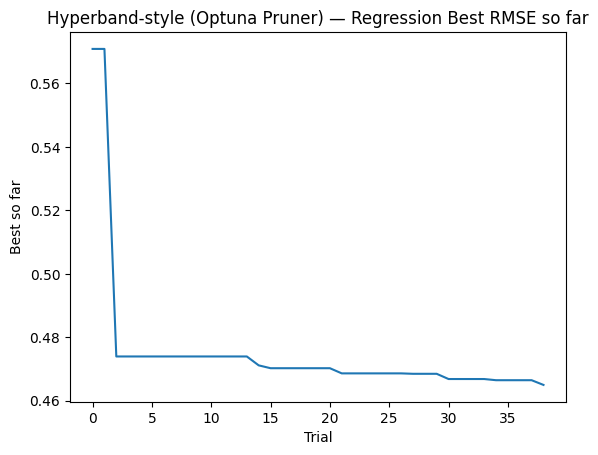

In [ ]:

@timer
def run_hyperband_style_reg(n_trials=50):
    sampler = TPESampler(seed=RANDOM_SEED)
    pruner = HyperbandPruner()
    study = optuna.create_study(direction="minimize", sampler=sampler, pruner=pruner)

    values = []
    def objective(trial):
        base_params = {
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "max_depth": trial.suggest_categorical("max_depth", [2, 3, 4, 5, 6, None]),
            "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 10, 64),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 10, 100, step=5),
            "l2_regularization": trial.suggest_float("l2_regularization", 0.0, 1.0),
        }
        val = incremental_cv_rmse(trial, base_params, budgets=(80, 150, 300), n_splits=3)
        values.append(val)
        return val

    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    best_params = study.best_params.copy()
    best_params["max_iter"] = 300

    best_model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", HistGradientBoostingRegressor(random_state=RANDOM_SEED, **best_params))
    ])
    best_model.fit(Xr_trainval, yr_trainval)
    pred = best_model.predict(Xr_test)
    test_rmse = math.sqrt(mean_squared_error(yr_test, pred))

    return best_params, float(study.best_value), test_rmse, values, study

(best_params, best_val_rmse, test_rmse, values, hb_study_r), elapsed = run_hyperband_style_reg(n_trials=50)
print("Best params:", best_params)
print(f"Best (multi-fidelity) val RMSE: {best_val_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Elapsed: {elapsed:.2f}s; completed trials: {len(values)}; pruned: {len([t for t in hb_study_r.trials if t.state==optuna.trial.TrialState.PRUNED])}")

plot_best_so_far(values, "Hyperband-style (Optuna Pruner) — Regression Best RMSE so far", higher_is_better=False)



## Method 5 — BOHB-style (solved)
BOHB combines:
- **BO** (model-based sampling, e.g., TPE)  
with
- **HB** (budget allocation + pruning)

We implement a practical BOHB-style approach using:
- **TPE sampler**
- **Hyperband pruner**
- budget = `max_iter`

(Strict BOHB has additional details, but pedagogically this is the same idea: model-based sampling + multi-fidelity.)


[I 2026-02-04 13:48:54,764] A new study created in memory with name: no-name-ffff79ec-def5-4957-91e1-21f2fa8cb738
[I 2026-02-04 13:48:59,439] Trial 0 finished with value: 0.9807344716695221 and parameters: {'learning_rate': 0.03574712922600244, 'max_depth': 2, 'max_leaf_nodes': 57, 'min_samples_leaf': 65, 'l2_regularization': 0.7080725777960455}. Best is trial 0 with value: 0.9807344716695221.
[I 2026-02-04 13:49:04,433] Trial 1 finished with value: 0.9679556481268868 and parameters: {'learning_rate': 0.010725209743171997, 'max_depth': 2, 'max_leaf_nodes': 38, 'min_samples_leaf': 50, 'l2_regularization': 0.2912291401980419}. Best is trial 0 with value: 0.9807344716695221.
[I 2026-02-04 13:49:08,809] Trial 2 finished with value: 0.986936182039693 and parameters: {'learning_rate': 0.08012737503998542, 'max_depth': 6, 'max_leaf_nodes': 38, 'min_samples_leaf': 65, 'l2_regularization': 0.046450412719997725}. Best is trial 2 with value: 0.986936182039693.
[I 2026-02-04 13:49:12,508] Trial 3 

Best params: {'learning_rate': 0.158833030391491, 'max_depth': 4, 'max_leaf_nodes': 21, 'min_samples_leaf': 10, 'l2_regularization': 0.30758087764004716, 'max_iter': 200}
Best BOHB-style val ROC-AUC: 0.9881
Test ROC-AUC: 0.9873
Elapsed: 230.87s; completed trials: 25; pruned: 35


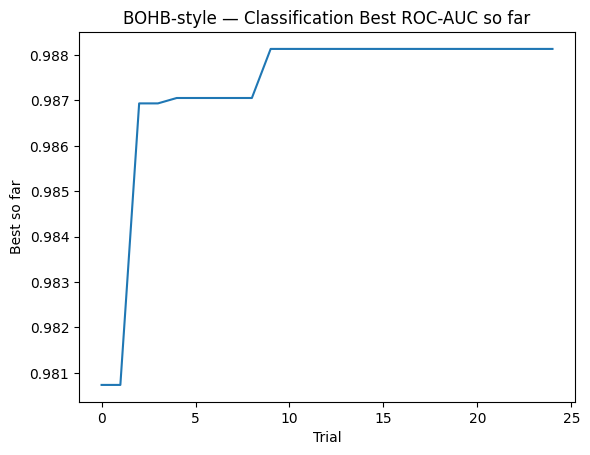

In [ ]:

@timer
def run_bohb_style_clf(n_trials=60):
    sampler = TPESampler(seed=RANDOM_SEED)      # BO-like sampler
    pruner = HyperbandPruner()                 # HB-like pruner
    study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)

    vals = []
    def objective(trial):
        # same params as before, but we explicitly expose the budget choices too
        base_params = {
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "max_depth": trial.suggest_categorical("max_depth", [2, 3, 4, 5, 6, None]),
            "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 10, 64),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 10, 100, step=5),
            "l2_regularization": trial.suggest_float("l2_regularization", 0.0, 1.0),
        }
        val = incremental_cv_auc(trial, base_params, budgets=(30, 60, 120, 200), n_splits=3)
        vals.append(val)
        return val

    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    best_params = study.best_params.copy()
    best_params["max_iter"] = 200

    best_model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", HistGradientBoostingClassifier(random_state=RANDOM_SEED, **best_params))
    ])
    best_model.fit(Xc_trainval, yc_trainval)
    proba = best_model.predict_proba(Xc_test)[:, 1]
    test_auc = roc_auc_score(yc_test, proba)

    return best_params, float(study.best_value), test_auc, vals, study

(best_params, best_val, test_auc, vals, bohb_study), elapsed = run_bohb_style_clf(n_trials=60)
print("Best params:", best_params)
print(f"Best BOHB-style val ROC-AUC: {best_val:.4f}")
print(f"Test ROC-AUC: {test_auc:.4f}")
print(f"Elapsed: {elapsed:.2f}s; completed trials: {len(vals)}; pruned: {len([t for t in bohb_study.trials if t.state==optuna.trial.TrialState.PRUNED])}")

plot_best_so_far(vals, "BOHB-style — Classification Best ROC-AUC so far", higher_is_better=True)


[I 2026-02-04 13:52:59,047] A new study created in memory with name: no-name-1648c908-60c5-49c0-b7ac-a868c081ce63
[I 2026-02-04 13:53:02,239] Trial 0 finished with value: 0.57086167398703 and parameters: {'learning_rate': 0.03574712922600244, 'max_depth': 2, 'max_leaf_nodes': 57, 'min_samples_leaf': 65, 'l2_regularization': 0.7080725777960455}. Best is trial 0 with value: 0.57086167398703.
[I 2026-02-04 13:53:04,948] Trial 1 finished with value: 0.698946152229532 and parameters: {'learning_rate': 0.010725209743171997, 'max_depth': 2, 'max_leaf_nodes': 38, 'min_samples_leaf': 50, 'l2_regularization': 0.2912291401980419}. Best is trial 0 with value: 0.57086167398703.
[I 2026-02-04 13:53:13,058] Trial 2 finished with value: 0.4739472258201496 and parameters: {'learning_rate': 0.08012737503998542, 'max_depth': 6, 'max_leaf_nodes': 38, 'min_samples_leaf': 65, 'l2_regularization': 0.046450412719997725}. Best is trial 2 with value: 0.4739472258201496.
[I 2026-02-04 13:53:18,305] Trial 3 finis

Best params: {'learning_rate': 0.05708953852403986, 'max_depth': None, 'max_leaf_nodes': 50, 'min_samples_leaf': 30, 'l2_regularization': 0.8671693962682521, 'max_iter': 300}
Best BOHB-style val RMSE: 0.4650
Test RMSE: 0.4466
Elapsed: 333.51s; completed trials: 26; pruned: 34


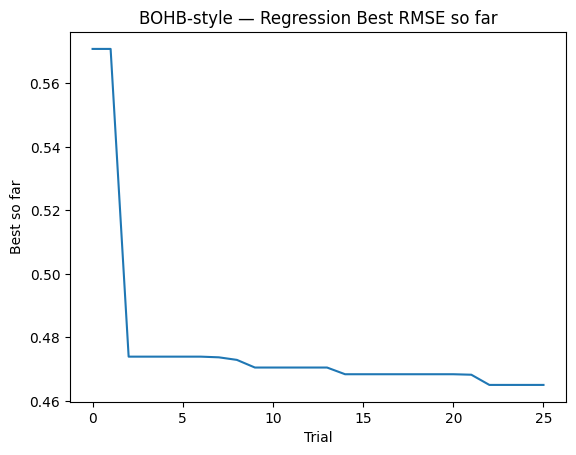

In [ ]:

@timer
def run_bohb_style_reg(n_trials=60):
    sampler = TPESampler(seed=RANDOM_SEED)
    pruner = HyperbandPruner()
    study = optuna.create_study(direction="minimize", sampler=sampler, pruner=pruner)

    vals = []
    def objective(trial):
        base_params = {
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "max_depth": trial.suggest_categorical("max_depth", [2, 3, 4, 5, 6, None]),
            "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 10, 64),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 10, 100, step=5),
            "l2_regularization": trial.suggest_float("l2_regularization", 0.0, 1.0),
        }
        val = incremental_cv_rmse(trial, base_params, budgets=(40, 100, 200, 300), n_splits=3)
        vals.append(val)
        return val

    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    best_params = study.best_params.copy()
    best_params["max_iter"] = 300

    best_model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", HistGradientBoostingRegressor(random_state=RANDOM_SEED, **best_params))
    ])
    best_model.fit(Xr_trainval, yr_trainval)
    pred = best_model.predict(Xr_test)
    test_rmse = math.sqrt(mean_squared_error(yr_test, pred))

    return best_params, float(study.best_value), test_rmse, vals, study

(best_params, best_val_rmse, test_rmse, vals, bohb_study_r), elapsed = run_bohb_style_reg(n_trials=60)
print("Best params:", best_params)
print(f"Best BOHB-style val RMSE: {best_val_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Elapsed: {elapsed:.2f}s; completed trials: {len(vals)}; pruned: {len([t for t in bohb_study_r.trials if t.state==optuna.trial.TrialState.PRUNED])}")

plot_best_so_far(vals, "BOHB-style — Regression Best RMSE so far", higher_is_better=False)



## Comparison summary (solved)
We collect results in compact leaderboards for classification and regression.

> You can re-run methods with different budgets (trials, grid size, CV folds) depending on lecture time.


In [ ]:

# Collect classification results quickly from what we already ran
# (These values are printed above; here we show how you'd aggregate in a real session.)

# NOTE: You may re-run this notebook from scratch. To keep it robust, we compute baselines again and store them.
clf_pipe.fit(Xc_trainval, yc_trainval)
proba = clf_pipe.predict_proba(Xc_test)[:, 1]
base_auc = roc_auc_score(yc_test, proba)

reg_pipe.fit(Xr_trainval, yr_trainval)
pred_r = reg_pipe.predict(Xr_test)
base_rmse = math.sqrt(mean_squared_error(yr_test, pred_r))

print(f"Baseline classification test ROC-AUC: {base_auc:.4f}")
print(f"Baseline regression test RMSE: {base_rmse:.4f}")


Baseline classification test ROC-AUC: 0.9744
Baseline regression test RMSE: 0.5690



### What to look for
- Which method improves fastest with a limited trial budget?
- Does better CV score always translate to better test score?
- How much time do multi-fidelity methods save (via pruning)?



## Student Task 1 (Classification) — **Your turn**
**Goal:** Improve test ROC-AUC over the baseline **without changing the estimator family**.

**What you must do:**
1. Use **Random Search** *or* **Optuna BO** (TPE) with **at least 30 trials**.
2. Add **one new hyperparameter** not tuned above (choose one):
   - `model__max_bins`
   - `model__early_stopping` (True/False)
   - `model__validation_fraction`
3. Report:
   - Best CV ROC-AUC
   - Test ROC-AUC
   - Best hyperparameters
   - A short 3–5 line reflection: *which hyperparameter mattered most and why?*


In [ ]:

# TODO (Student):
# - Choose ONE method (Random Search or Optuna TPE)
# - Extend the search space by ONE new hyperparameter (from the list above)
# - Run >= 30 trials
# - Print the requested report

# HINT: if you use RandomizedSearchCV, you can add keys like "model__early_stopping": [True, False]
# HINT: for Optuna, add trial.suggest_* and pass into HistGradientBoostingClassifier(...)

raise NotImplementedError("Student Task 1: implement your tuning experiment here.")



## Student Task 2 (Regression) — **Your turn**
**Goal:** Reduce test RMSE compared to the baseline while keeping the same estimator family.

**What you must do:**
1. Use **Hyperband-style pruning** or **BOHB-style** (TPE + HyperbandPruner).
2. Treat `max_iter` as the budget and use **at least 3 budgets**, e.g. `(50, 150, 300)`.
3. Report:
   - Best validation RMSE
   - Test RMSE
   - # pruned trials
   - Best hyperparameters
   - A short 3–5 line reflection: *did pruning help runtime? did it hurt quality?*


In [ ]:

# TODO (Student):
# - Use Optuna + HyperbandPruner (or reuse the incremental_cv_rmse helper)
# - Ensure you use >= 3 budgets
# - Ensure you report pruned trials count and final test RMSE

raise NotImplementedError("Student Task 2: implement your multi-fidelity tuning experiment here.")



## Wrap-up
You have now tuned a **single estimator** using multiple HPO strategies.

Next step (in your separate AutoML notebook): CASH-style AutoML chooses **the algorithm + hyperparameters** under time/budget constraints.
